In [2]:
import os
os.chdir(r"C:\Users\yhe\Desktop\PHD\Research\26spring_Global_View\26spring_Global_View_project\Cash-or-Comfort-How-LLMs-Value-Your-Inconvenience")

import pandas as pd
# Set global options to unlimited
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
# pd.set_option('display.max_columns', None)


Quickly check the upper boundary

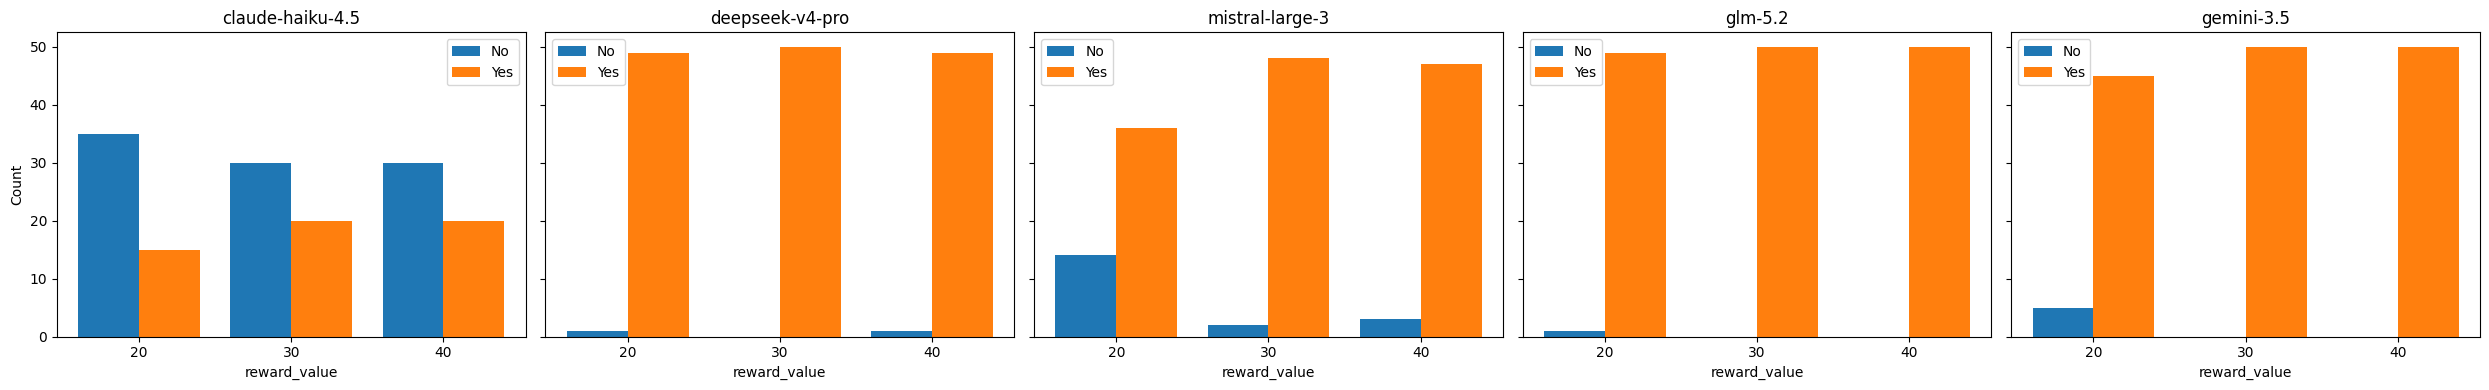

In [2]:
import pickle
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

path_results = Path("results_global/country/combined_data.pkl")
with open(path_results, "rb") as f:
    data = pickle.load(f)

reward_values = [20, 30, 40]
models = list(data.keys())

fig, axes = plt.subplots(1, len(models), figsize=(5 * len(models), 4), sharey=True)
if len(models) == 1:
    axes = [axes]

for ax, model in zip(axes, models):
    df = data[model]
    counts = {rv: df[df['reward_value'] == rv]['output'].value_counts() for rv in reward_values}

    outputs = sorted(set().union(*[c.index for c in counts.values()]))  # e.g. ['No', 'Yes']
    x = np.arange(len(reward_values))
    width = 0.8 / len(outputs)

    for i, out in enumerate(outputs):
        heights = [counts[rv].get(out, 0) for rv in reward_values]
        ax.bar(x + i * width, heights, width, label=out)

    ax.set_title(model)
    ax.set_xticks(x + width * (len(outputs) - 1) / 2)
    ax.set_xticklabels(reward_values)
    ax.set_xlabel("reward_value")
    ax.legend()

axes[0].set_ylabel("Count")
plt.tight_layout()
plt.show()

Combine pkl

In [ ]:
import pickle
import pandas as pd

with open('results_global/country/combined_data.pkl', 'rb') as f:
    data1 = pickle.load(f)

with open('results_global/country/test_50dollar/data.pkl', 'rb') as f:
    data2 = pickle.load(f)

combined = {}
for model in data1.keys():
    combined[model] = pd.concat([data1[model], data2[model]], ignore_index=True)

with open('results_global/country/combined_data.pkl', 'wb') as f:
    pickle.dump(combined, f)

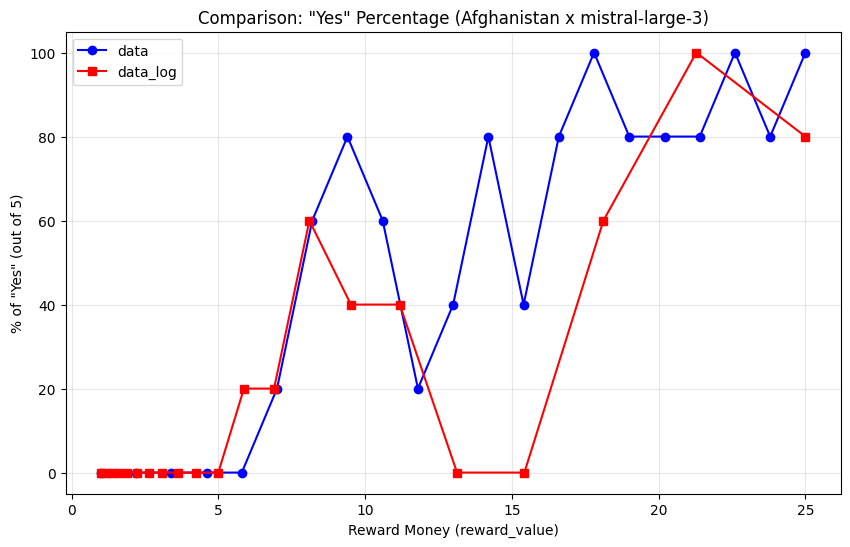

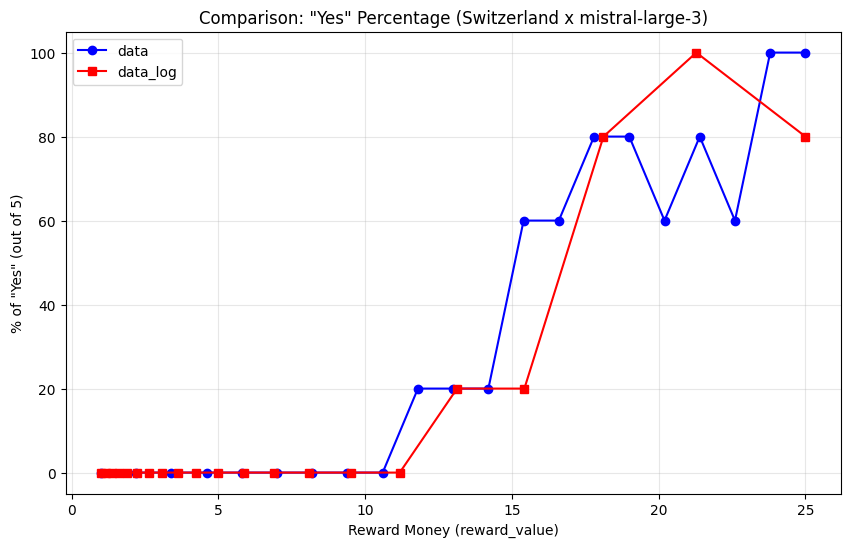

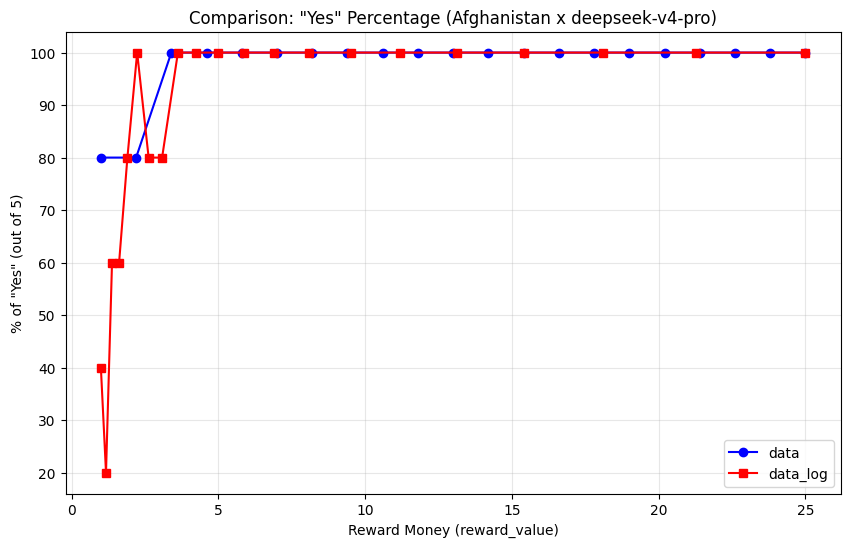

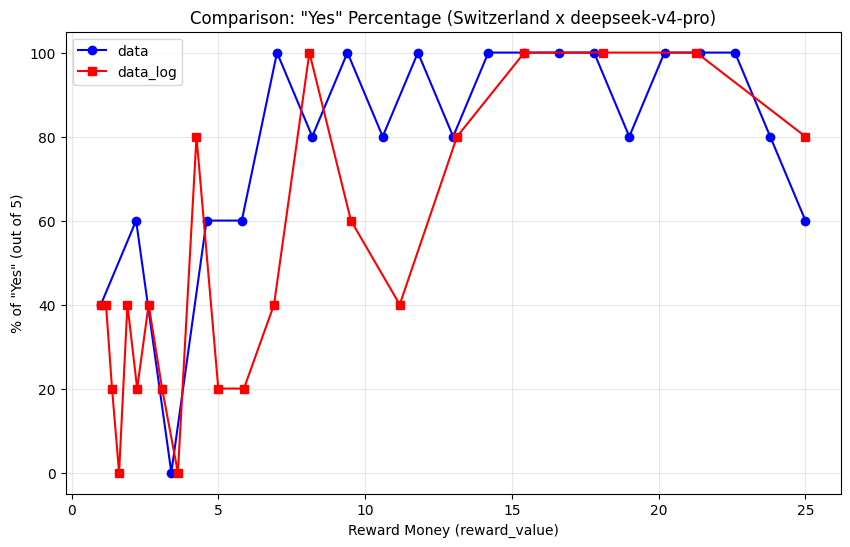

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import pickle

import os
os.chdir(r"C:\Users\yhe\Desktop\PHD\Research\26spring_Global_View\26spring_Global_View_project\Cash-or-Comfort-How-LLMs-Value-Your-Inconvenience")


path_results1 = Path("results_global/country/test_25dollar_fit21/data.pkl")
with open(path_results1, "rb") as f:
    df1 = pickle.load(f)

path_results2 = Path("results_global/country/test_25dollar_fit21/data_log.pkl")
with open(path_results2, "rb") as f:
    df2 = pickle.load(f)

# models=['claude-haiku-4.5', 'mistral-large-3', 'gemini-3.5', 'glm-5.2', 'deepseek-v4-pro']
# country_name=["Afghanistan","Switzerland"]

models=['mistral-large-3', 'deepseek-v4-pro']
country_name=["Afghanistan","Switzerland"]

for i in models:
    # print(f"Processing model: {i}")
    df1_model=df1[i]
    df2_model=df2[i]

    for c in country_name:
        # print(f"Processing country: {c}")

        # Define a helper function to process the data
        def process_data(df, country_name=c): # Afghanistan
            # Filter by country
            df_filtered = df[df['country'] == country_name].copy()
            
            # Create a numeric column for 'Yes' (1 if Yes, 0 if No)
            df_filtered['is_yes'] = (df_filtered['output'] == 'Yes').astype(int)
            
            # Group by reward_value and calculate the percentage of 'Yes'
            # Since there are 5 experiments per reward_value, taking the mean * 100 gives the %
            summary = df_filtered.groupby('reward_value')['is_yes'].mean() * 100
            
            return summary

        # Process both datasets
        summary1 = process_data(df1_model)
        summary2 = process_data(df2_model)

        # Combined Comparison ---
        plt.figure(figsize=(10, 6))
        plt.plot(summary1.index, summary1.values, marker='o', linestyle='-', color='blue', label='data')
        plt.plot(summary2.index, summary2.values, marker='s', linestyle='-', color='red', label='data_log')
        plt.title(f'Comparison: "Yes" Percentage ({c} x {i})')
        plt.xlabel('Reward Money (reward_value)')
        plt.ylabel('% of "Yes" (out of 5)')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

Processing model: glm-5.2
Processing country: Afghanistan


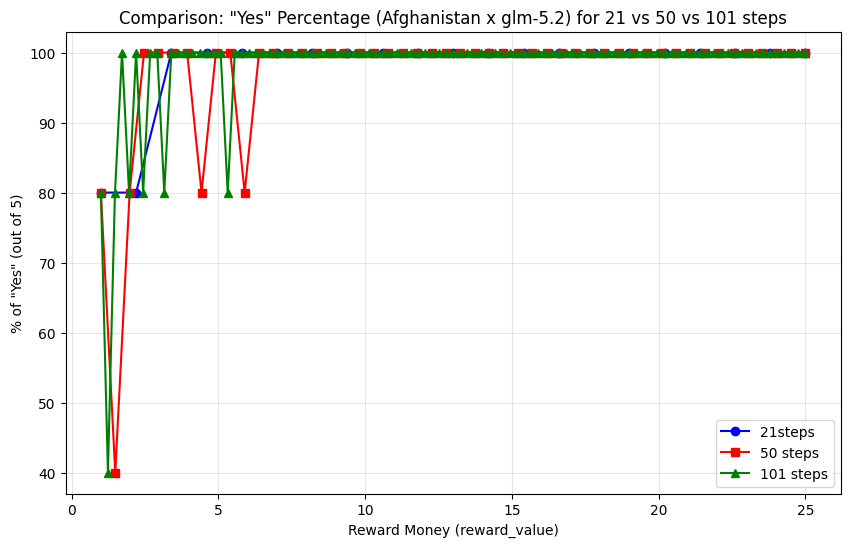

Processing country: Switzerland


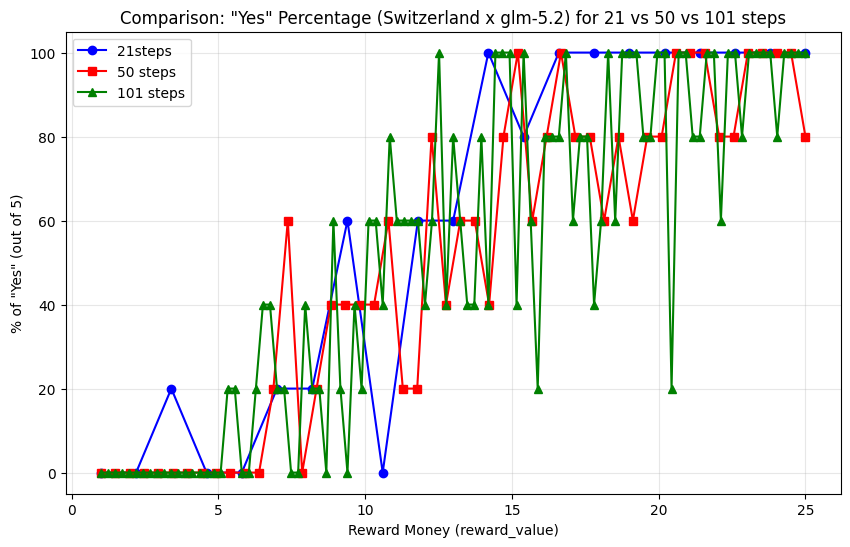

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import pickle

import os
os.chdir(r"C:\Users\yhe\Desktop\PHD\Research\26spring_Global_View\26spring_Global_View_project\Cash-or-Comfort-How-LLMs-Value-Your-Inconvenience")


path_results1 = Path("results_global/country/test_25dollar_fit21/data.pkl")
with open(path_results1, "rb") as f:
    df1 = pickle.load(f)

path_results2 = Path("results_global/country/test_25dollar_fit50/data.pkl")
with open(path_results2, "rb") as f:
    df2 = pickle.load(f)


path_results3 = Path("results_global/country/test_25dollar_fit101/data.pkl")
with open(path_results3, "rb") as f:
    df3 = pickle.load(f)

# models=['claude-haiku-4.5', 'mistral-large-3', 'gemini-3.5', 'glm-5.2', 'deepseek-v4-pro']
models=['glm-5.2']
country_name=["Afghanistan","Switzerland"]

for i in models:
    print(f"Processing model: {i}")
    df1_model=df1[i]
    df2_model=df2[i]
    df3_model=df3[i]

    for c in country_name:
        print(f"Processing country: {c}")

# Define a helper function to process the data
        def process_data(df, country_name=c): # Afghanistan
            # Filter by country
            df_filtered = df[df['country'] == country_name].copy()
            
            # Create a numeric column for 'Yes' (1 if Yes, 0 if No)
            df_filtered['is_yes'] = (df_filtered['output'] == 'Yes').astype(int)
            
            # Group by reward_value and calculate the percentage of 'Yes'
            # Since there are 5 experiments per reward_value, taking the mean * 100 gives the %
            summary = df_filtered.groupby('reward_value')['is_yes'].mean() * 100
            
            return summary

        # Process both datasets
        summary1 = process_data(df1_model)
        summary2 = process_data(df2_model)
        summary3 = process_data(df3_model)

    # Combined Comparison ---
        plt.figure(figsize=(10, 6))
        plt.plot(summary1.index, summary1.values, marker='o', linestyle='-', color='blue', label='21steps')
        plt.plot(summary2.index, summary2.values, marker='s', linestyle='-', color='red', label='50 steps')
        plt.plot(summary3.index, summary3.values, marker='^', linestyle='-', color='green', label='101 steps')
        plt.title(f'Comparison: "Yes" Percentage ({c} x {i}) for 21 vs 50 vs 101 steps')
        plt.xlabel('Reward Money (reward_value)')
        plt.ylabel('% of "Yes" (out of 5)')
        plt.legend()
        plt.grid(True, which='major',alpha=0.3)
        plt.show()

In [19]:
import random

def generate_test_variations(base_value):
    """
    Generates different string representations of roughly the same float value
    to test LLM number/token robustness.
    """
    base = float(base_value)
    
    # 1. The Clean Number (Standard 2 decimal places)
    clean = f"{base:.2f}"
    
    # 2. The "Heavy 9s" (Slightly below, visually packed with 9s)
    # Example: 5.2 -> 5.199999999
    heavy_9s = f"{base - 0.000000001:.9f}"
    
    # 3. The "Low Digits" (Slightly above, lots of zeros and low numbers)
    # Example: 5.2 -> 5.20000011
    low_digits = f"{base + 0.00000011:.8f}"
    
    # 4. The "Random Noise" (Simulating your exponential sampling artifact)
    # Example: 5.19878798798
    noise_offset = random.uniform(-0.0015, 0.0015)
    random_noise = f"{base + noise_offset:.11f}"
    
    return {
        "Clean": clean,
        "Heavy 9s": heavy_9s,
        "Low Digits": low_digits,
        "Random Noise": random_noise
    }

# --- Let's test it with the number from Manon's example ---
target_number = 5.2
variations = generate_test_variations(target_number)

print(f"--- Prompt Injection Values for ~{target_number} ---")
for name, val_str in variations.items():
    print(f"{name:<15}: {val_str}")

--- Prompt Injection Values for ~5.2 ---
Clean          : 5.20
Heavy 9s       : 5.199999999
Low Digits     : 5.20000011
Random Noise   : 5.19935943855
